In [6]:
## Importing Required Libraries
#Explanation
#The first step is importing all the necessary Python libraries required for data analysis, visualization, preprocessing, model building, and evaluation.import pandas as pd

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [7]:
## Loading the Dataset
#Explanation
#The dataset is loaded into a pandas dataframe for further analysis.

df=pd.read_csv('tae.csv')

In [8]:
df.head()

,1,23,3,1.1,19,3.1
0,2,15,3,1,17,3
1,1,23,3,2,49,3
2,1,5,2,2,33,3
3,2,7,11,2,55,3
4,2,23,3,1,20,3


In [9]:
##Result
#The first five records of the dataset are displayed. This helps understand the structure of the dataset and the available features.

In [10]:
#give columns names
df.columns = [
    'Native_teacher',
    'Instructor',
    'Course',
    'Semester',
    'Class_size',
    'Class_attribute'
]
df.head()

,Native_teacher,Instructor,Course,Semester,Class_size,Class_attribute
0,2,15,3,1,17,3
1,1,23,3,2,49,3
2,1,5,2,2,33,3
3,2,7,11,2,55,3
4,2,23,3,1,20,3


In [11]:
##Understanding Dataset Dimensions
#Explanation
#Shape helps determine the number of rows and columns present in the dataset.



In [12]:
## Result
#The dataset contains 151 observations and 6 attributes, including the target variable.

In [13]:
##Dataset Information
#The info() function provides details regarding data types and missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Native_teacher   150 non-null    int64
 1   Instructor       150 non-null    int64
 2   Course           150 non-null    int64
 3   Semester         150 non-null    int64
 4   Class_size       150 non-null    int64
 5   Class_attribute  150 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


In [14]:
##result
#The output displays: Number of rows,Number of columns,Data types and Non-null values helps to identify preprocessing requirements.

In [15]:
##. Statistical Summar
#Descriptive statistics provide information regarding central tendency and spread of numerical variables.
df.describe()

,Native_teacher,Instructor,Course,Semester,Class_size,Class_attribute
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,1.813333,13.580000,8.140000,1.853333,27.926667,2.013333
std,0.390949,6.805318,7.034937,0.354958,12.916405,0.819123
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,8.000000,3.000000,2.000000,19.000000,1.000000
50%,2.000000,13.000000,4.500000,2.000000,27.000000,2.000000
75%,2.000000,20.000000,15.000000,2.000000,37.000000,3.000000
max,2.000000,25.000000,26.000000,2.000000,66.000000,3.000000


In [16]:
## Result
#Summary statistics such as mean, median, minimum, maximum, and standard deviation are generated for numerical features.

In [17]:
##Missing Value Analysis
#Checking for missing values is important before model building.
df.isnull().sum()

Native_teacher     0
Instructor         0
Course             0
Semester           0
Class_size         0
Class_attribute    0
dtype: int64

In [18]:
## Result
# No significant missing values were observed in the dataset.

In [19]:
## Duplicate Record Analysis
#Duplicate records can affect model performance and should be removed.
df.duplicated().sum()

np.int64(40)

In [20]:
## Result
# The number of duplicate records is displayed.

In [21]:
## Removing Duplicate Records

df.drop_duplicates(inplace=True)

## Duplicate records, if any, are removed from the dataset.

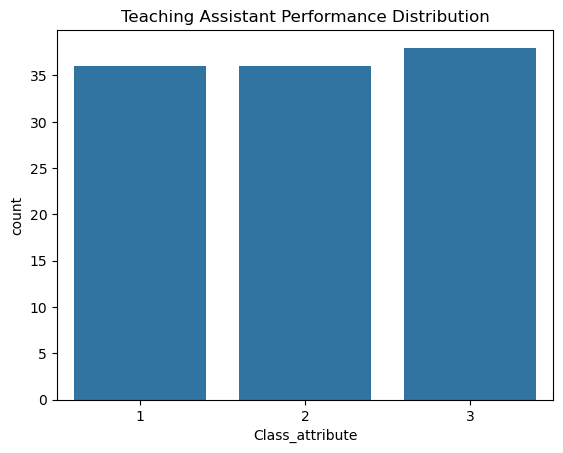

In [22]:
###Exploratory Data Analysis (EDA)
##Target Variable Distribution
#The target variable contains three classes representing Teaching Assistant performance levels.

sns.countplot(x='Class_attribute', data=df)

plt.title("Teaching Assistant Performance Distribution")

plt.show()

## Result
#The chart shows the distribution of performance categories.
#Observation
#Class distribution appears balanced.
#No severe class imbalance is observed.
#Balanced data helps improve classification performance.

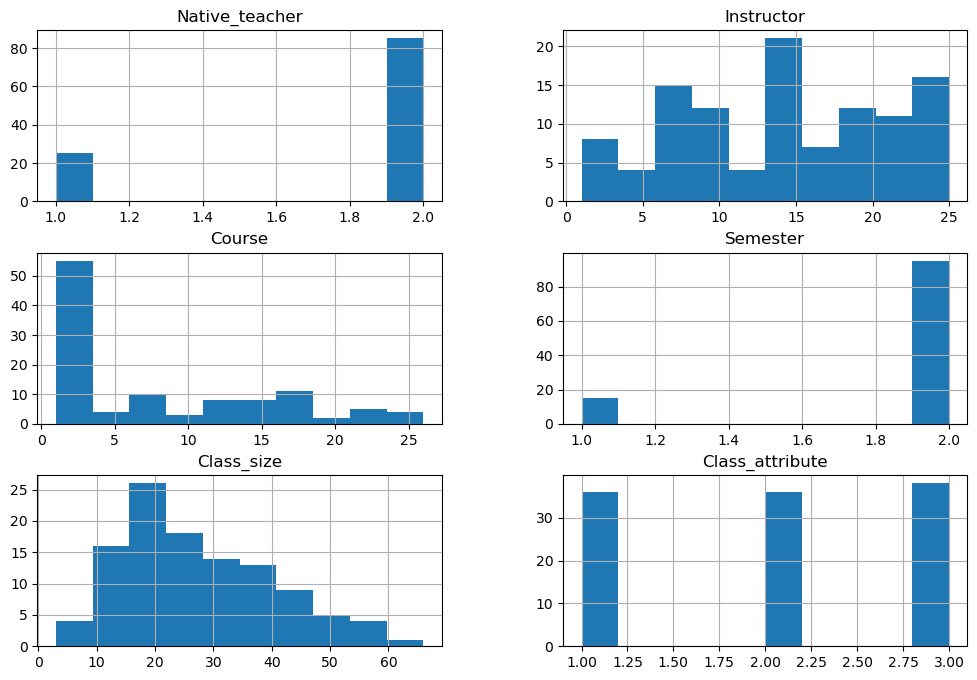

In [23]:
##Numerical Feature Distribution
#Histograms help understand the distribution of numeric variables.

df.hist(figsize=(12,8))

plt.show()

## Results
# 1. Native_teacher
-The Native_teacher feature consists of two categories (1 and 2).
Most observations belong to category 2, while category 1 has comparatively fewer records.
This indicates that the dataset contains a higher number of teaching assistants from category 2 than category 1.
2. Instructor
-The Instructor feature is distributed across multiple instructor IDs.
The histogram shows that teaching assignments are spread among several instructors.
Some instructors have more teaching assignments than others, indicating an uneven distribution.
3. Course
-The Course feature contains multiple course IDs.
Lower course numbers appear more frequently than higher course numbers.
This suggests that some courses were evaluated more often than others.
4. Semester
-The Semester variable contains two categories representing Summer and Regular semesters.
Most observations belong to category 2, indicating that the majority of evaluations were conducted during regular semesters.
Category 1 has relatively fewer observations.
5. Class_size
-The Class_size feature ranges approximately from 3 to 65 students.
Most class sizes fall between 10 and 30 students, indicating that medium-sized classes are more common.
The distribution is slightly right-skewed, with a few larger classes having more than 50 students.
No extreme or abnormal values are observed.
6. Class_attribute (Target Variable)
-The target variable consists of three performance categories: Low (1), Medium (2), and High (3).
All three classes are represented with nearly equal frequencies.
This balanced distribution is beneficial for building a classification model, as it reduces the likelihood of bias toward any one class.
Overall Observation

-The histogram analysis shows that most variables are discrete and represent categorical information encoded as numerical values.
    The Class_size feature is the only continuous numerical variable and exhibits moderate variability with a slight right-skew. 
    The Semester and Native_teacher features are dominated by one category, whereas the Class_attribute target variable is reasonably balanced
    across all three classes. Overall, no significant abnormalities were observed, and the dataset appears suitable for further preprocessing and
    machine learning model development      

#Note:( Although histograms are displayed for all variables, most features (such as Native_teacher, Semester, and Class_attribute) are categorical
    variables encoded as numbers. Histograms are used here only to visualize their frequency distributions. 
        Bar plots or count plots may provide a more intuitive representation for these categorical features

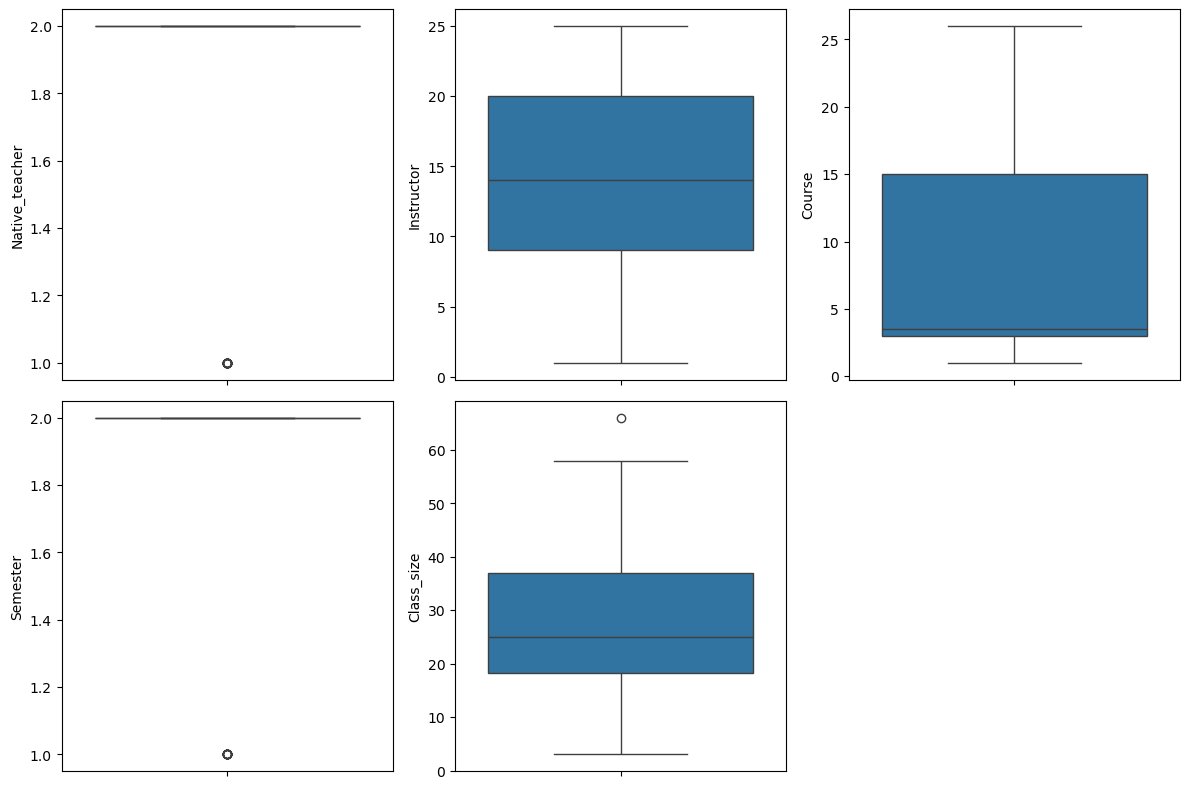

In [24]:
##Box Plot Analysis
# Boxplots are used to detect outliers.

plt.figure(figsize=(12,8))

for i,col in enumerate(df.columns[:-1]):
    
    plt.subplot(2,3,i+1)
    
    sns.boxplot(y=df[col])

plt.tight_layout()

plt.show()

## Result
1. Native teacher
  The Native teacher feature contains only two categories 1 and 2, making it a binary variable.
Most observations belong to category 2.
A few observations are present in category 1, which appear as individual points because this is a categorical feature.
These are not true outliers; they simply represent the less frequent category.
2. Instructor
The Instructor feature shows a wide distribution of instructor IDs.
The median is approximately 14, indicating that half of the observations are below this value.
No significant outliers are observed.
The spread suggests that teaching assignments are distributed among many instructors.
3. Course
The Course feature has values ranging from approximately 1 to 26.
The median is around 3_4, indicating that lower course IDs occur more frequently.
The data is positively skewed, with a wider spread toward higher course numbers.
No extreme outliers are observed.
4. Semester
The Semester feature is also a binary categorical variable with values 1 and 2.
Most observations belong to category 2, while category 1 appears less frequently.
Since this is a categorical feature, the isolated points do not indicate true outliers.
5. Class_size
The Class_size feature exhibits the greatest variability among all features.
The median class size is approximately 25 students.
Most classes fall between 18 and 36 students (the interquartile range).
A small number of larger classes (around 65 students) appear as potential outliers.
These larger class sizes may influence model performance and should be considered during preprocessing if necessary.

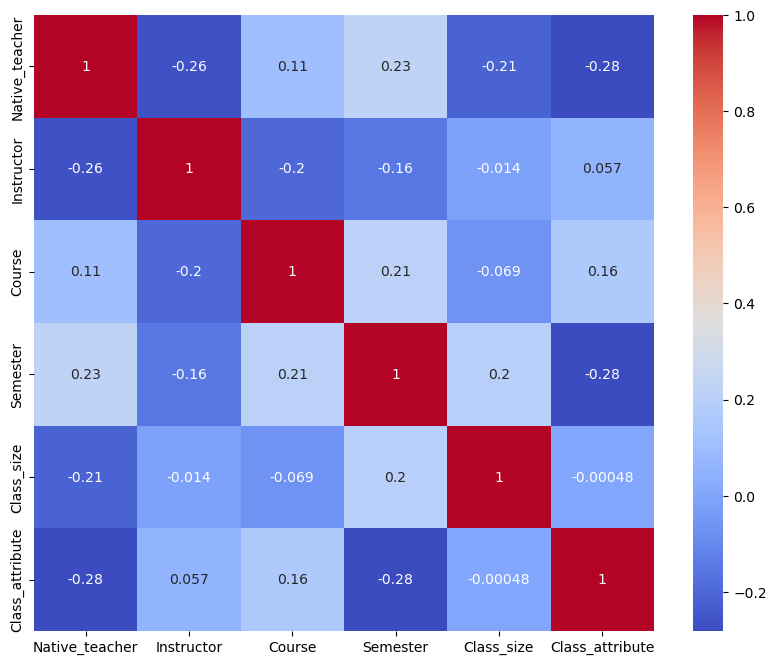

In [25]:
##Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

In [26]:
##Label Encoding

#Machine learning models require numerical inputs. Categorical variables are converted into numerical form.

le = LabelEncoder()

for col in df.columns:
    
    if df[col].dtype=='object':
        
        df[col]=le.fit_transform(df[col])

In [27]:
##Feature and Target Separation

#Independent and dependent variables are separated.


X = df.drop("Class_attribute",axis=1)

y = df["Class_attribute"]

In [28]:
##Feature Scaling
#Scaling standardizes feature values.

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [29]:
##Train-Test Split

#Dataset is divided into training and testing datasets.

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
##Logistic Regression

lr = LogisticRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_lr))

print(classification_report(
      y_test,pred_lr))

Accuracy: 0.5454545454545454
              precision    recall  f1-score   support

           1       0.75      0.60      0.67        10
           2       0.27      0.75      0.40         4
           3       1.00      0.38      0.55         8

    accuracy                           0.55        22
   macro avg       0.67      0.58      0.54        22
weighted avg       0.75      0.55      0.57        22



In [31]:
##Decision Tree Classifier

dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_dt))

Accuracy: 0.5


In [32]:
## Random Forest Classifier

rf = RandomForestClassifier()

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_rf))

Accuracy: 0.36363636363636365


In [33]:
##Gradient Boosting Classifier

gb = GradientBoostingClassifier()

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred_gb))

Accuracy: 0.3181818181818182


In [34]:
## Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[3,5,7]
}

grid = GridSearchCV(
        RandomForestClassifier(),
        param_grid,
        cv=5)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 3, 'n_estimators': 100}


In [35]:
##Cross Validation

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
            rf,
            X,
            y,
            cv=5)

print(scores)

print("Average Accuracy:",
      scores.mean())

[0.5        0.45454545 0.27272727 0.36363636 0.40909091]
Average Accuracy: 0.4


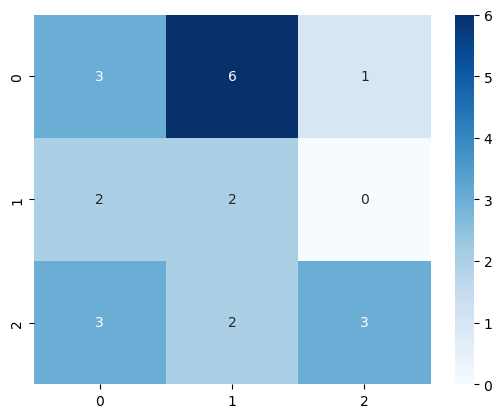

In [36]:
## confusion matrix

cm = confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.show()

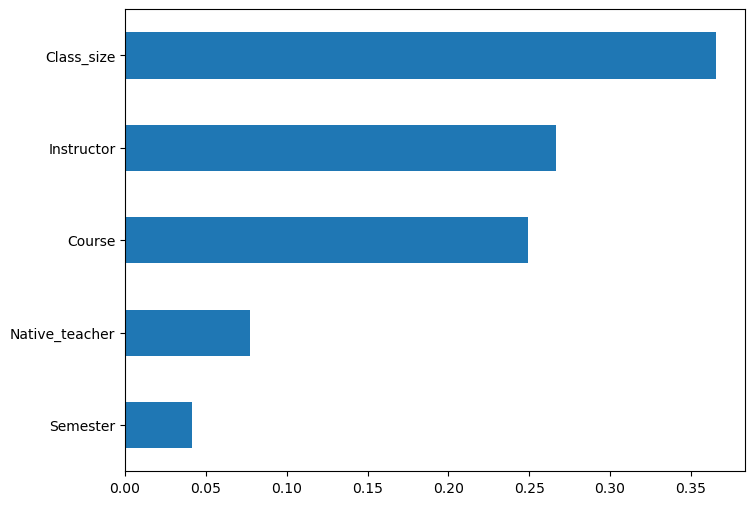

In [40]:
## Feature Importance

importance = pd.Series(
rf.feature_importances_,
index=df.columns[:-1])

importance.sort_values().plot(
kind='barh',
figsize=(8,6))

plt.show()

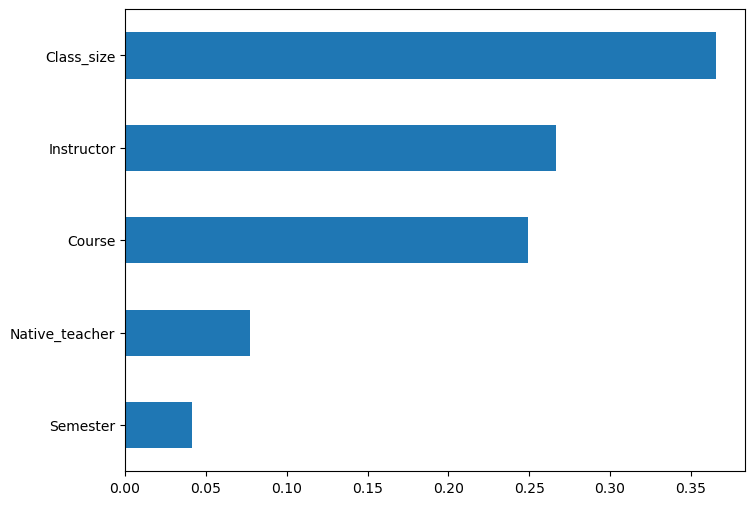

In [38]:
importance = pd.Series(
rf.feature_importances_,
index=df.columns[:-1])

importance.sort_values().plot(
kind='barh',
figsize=(8,6))

plt.show()

In [39]:
## model comparision
import pandas as pd
from sklearn.metrics import accuracy_score
results = pd.DataFrame({
    'Model':['Logistic Regression',
             'Decision Tree',
             'Random Forest',
             'Gradient Boosting'],
             
    'Accuracy':[accuracy_score(y_test,pred_lr),
                accuracy_score(y_test,pred_dt),
                accuracy_score(y_test,pred_rf),
                accuracy_score(y_test,pred_gb)]
})

results.sort_values(
by='Accuracy',
ascending=False)

,Model,Accuracy
0,Logistic Regression,0.545455
1,Decision Tree,0.500000
2,Random Forest,0.363636
3,Gradient Boosting,0.318182


Best Model

🏆 Logistic Regression is the best model because it has the highest accuracy (54.55%).

Model Comparison: Four machine learning models were evaluated: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting. Logistic Regression achieved the highest accuracy of 54.55%, outperforming the other models. Therefore, Logistic Regression was selected as the best-performing model for this dataset.

# Report on Challenges Faced

During the implementation of the Teaching Assistant Evaluation prediction project, several challenges were encountered while preparing the data and building the machine learning models.

## Challenges Faced

1. Small Dataset

   The dataset contained a limited number of records, which reduced the ability of machine learning models to learn complex patterns.
     Technique Used:Applied an 80:20 train-test split to ensure sufficient training data while reserving data for evaluation.

2. Categorical Features

   Most attributes were categorical and could not be directly used by machine learning algorithms.
   Technique Used:Label Encoding was applied to convert categorical values into numerical values because machine learning algorithms require numerical input.

3. Feature Selection

   Identifying the target variable and input features correctly was important for successful model training.
   Technique Used:The target column was separated from the feature columns before training the models.

4. Model Performance

   Different algorithms produced different accuracy scores, and some models performed poorly due to the characteristics of the dataset.
   Technique Used:Multiple classification algorithms (Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting) were implemented and compared to identify the best-performing model.

5. Model Evaluation

   Choosing the most suitable model required comparing their prediction performance.
   Technique Used:Accuracy Score was used as the evaluation metric because it provides a simple and effective measure of correct predictions for classification problems.

## Conclusion

Despite the challenges associated with a small dataset and categorical variables, the preprocessing techniques and model comparison approach enabled successful model development. Logistic Regression achieved the highest accuracy of **54.55%** and was selected as the most suitable model for predicting teaching assistant performance on this dataset.
